# Batch Constrained Q-Learning (BCQ): Continuous Action Version

## 1. Core Idea
The core idea of BCQ is:
- Batch Constrained: Achieving a similar state-action distribution between the $\{(s,\pi(\cdot \mid s))\}$ and the buffer $\mathcal{D}$. 
- Policy Improvement: The action $a$ at state $s$ should be with the highest value (DQN-like)

## 2. Implementation
### 2.1 Continuous DQN-like Training
- Get a batch of state-action pairs $\mathcal{D}$ in some way.
- To achieve a continuous action, a generative model $G_\omega$ is used to analog the continuous actor. A amount of 'similar' state-actions $(s,a_{i})$ are generated by a well-trained generative model $G_\omega$ (here use a VAE).
- DQN on the batch ('No interaction version'):
  - To get a deterministic action $\tilde a_i$, the action $a_i$ is obtained by the end to end map $G_\omega$ and perturbed by a noise $\xi_\theta$.
  - Solve BOE to estimate the optimal Q-value similar to DQN.
- Action with highest value is selected among $\{ \tilde a_i, \forall i\}$ as the final action.
$$
\begin{array}{l}
{\pi _\theta }(\tilde a,s) = \mathop {{\mathop{\rm argmax}\nolimits} }\limits_{{{\tilde a}_i}} {Q_\phi }\left( {s,\tilde a_i} \right)\\
{\text{where}}\\
{{\tilde a}_i} = {a_i} + {\xi _\theta }\left( {s,{a_i}} \right){\rm{,}}\\
{a_i}\sim{G_{\omega} }( \cdot \mid s),~{\text{for}}~ i = 1,2,\dots N
\end{array}
$$

# 3. Codes

In [1]:
import os
import pickle
from typing import Tuple
import collections
import random
import copy

import numpy as np
import gymnasium as gym
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
class Offline_Buffer():
    def __init__(self,
                 capacity:int,
                 device:torch.device = torch.device("cpu")
                 ) -> None:
        self.device = device
        self.buffer = collections.deque(maxlen=capacity)
        
    def append(self,exp_data:tuple) -> None:
        self.buffer.append(exp_data)
         
    def to_tensor(self) -> None:
        obs, action, reward, next_obs, done = zip(*self.buffer)
        self.obs = torch.tensor(np.array(obs),dtype=torch.float32,device=self.device)
        self.action = torch.tensor(np.array(action),dtype=torch.float32,device=self.device)
        self.reward = torch.tensor(np.array(reward),dtype=torch.float32,device=self.device).unsqueeze(-1)
        self.next_obs = torch.tensor(np.array(next_obs),dtype=torch.float32,device=self.device)
        self.done = torch.tensor(np.array(done),dtype=torch.float32,device=self.device).unsqueeze(-1)
        
    def sample(self,batch_size:int) -> Tuple[torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor]:
        idx = np.random.choice(len(self.obs),batch_size)
          
        return self.obs[idx],self.action[idx],self.reward[idx],self.next_obs[idx],self.done[idx]
    
    def __len__(self) -> int:
        return len(self.buffer)
    
    def save_to_disk(self, filename:str) -> None:
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        with open(filename, 'wb') as f:
            pickle.dump(self.buffer, f)
    
    def load_from_disk(self, filename:str) -> None:
        with open(filename, 'rb') as f:
            self.buffer = pickle.load(f)
        self.to_tensor()
        
        
class BCQ_Agent():
    '''VAE + DQN(no interaction)'''
    def __init__(self,
                 buffer:Offline_Buffer,
                 batch_size:int,
                 target_update_tau:float, # The parameter for soft update
                 actor_network:torch.nn.Module, 
                 Q1_network:torch.nn.Module,
                 Q2_network:torch.nn.Module,
                 actor_optimizer:torch.optim.Optimizer,
                 Q1_optimizer:torch.optim.Optimizer,
                 Q2_optimizer:torch.optim.Optimizer,
                 vae:torch.nn.Module,
                 vae_optimizer:torch.optim.Optimizer,
                 sampled_action_num:int = 100,
                 gamma:float = 0.9,
                 lam:float = 0.75,
                 double_Q_enabled:bool = True,
                 device:torch.device = torch.device("cpu")
                 ) -> None:
        
        self.step_counter = 0
        
        self.buffer = buffer
        self.device = device
        self.batch_size = batch_size
    
        self.target_update_tau = target_update_tau
        
        self.Q1_network = Q1_network
        self.Q2_network = Q2_network
        self.target_Q1_network = copy.deepcopy(Q1_network).to(self.device)
        self.target_Q2_network = copy.deepcopy(Q2_network).to(self.device)
        self.actor_network = actor_network
        self.target_actor_network = copy.deepcopy(actor_network).to(self.device)
        
        self.Q1_optimizer = Q1_optimizer
        self.Q2_optimizer = Q2_optimizer
        self.actor_optimizer = actor_optimizer
        
        self.vae = vae
        self.vae_optimizer = vae_optimizer
        self.sampled_action_num = sampled_action_num
        
        self.gamma = gamma
        self.lam = lam
        self.double_Q_enabled = double_Q_enabled
        
    def get_action(self,obs:np.ndarray) -> np.ndarray:
        '''
        Choose an action with the highest Q value
        '''   
        obs = torch.tensor(obs,dtype=torch.float32).to(self.device)
        obs = obs.reshape(1,-1).repeat(self.sampled_action_num,1) # repeat the observation for sampled_action_num times
        tilde_action = self.actor_network(obs,self.vae.generate(obs)) # tilde_action = VAE(obs) + Noise(obs,action)
        q_list = self.Q1_network(obs,tilde_action)
        idx = torch.argmax(q_list).item()
        action = tilde_action[idx].detach().cpu().numpy()
        return action
    
    def train_vae(self,obs:torch.Tensor,action:torch.Tensor) -> None:
        x_hat, mu, sigma = self.vae(obs,action)
        reg_loss = F.mse_loss(x_hat,action)
        var = torch.pow(torch.exp(sigma),2)
        kld_loss = -0.5 * torch.mean(1+torch.log(var)-torch.pow(mu,2)-var)
        loss = reg_loss + 0.5 * kld_loss
        
        self.vae_optimizer.zero_grad()
        loss.backward()
        self.vae_optimizer.step()
        
    
    def Q_approximation(self) -> None:        
        self.step_counter += 1
        obs, action,reward, next_obs, done = self.buffer.sample(self.batch_size)
        self.train_vae(obs,action)
        self.batch_Q_approximation(obs,action,reward,next_obs,done)
        self.batch_actor_update(obs) # train actor
        self.soft_update_network(self.Q1_network,self.target_Q1_network) # soft update target networks
        if self.double_Q_enabled:
            self.soft_update_network(self.Q2_network,self.target_Q2_network)
            
        self.soft_update_network(self.actor_network,self.target_actor_network)
    
    
    def batch_Q_approximation(self,
                              obs:torch.Tensor,
                              action:torch.Tensor,
                              reward:torch.Tensor,
                              next_obs:torch.Tensor,
                              done:torch.Tensor) -> None:
        """To update the main critic network"""
        batch_size = obs.shape[0]
        current_Q1 = self.Q1_network(obs,action)
        if self.double_Q_enabled:
            next_obs = torch.repeat_interleave(next_obs, 10, dim=0) # repeat the next_obs for 10 for sampling 10 actions
            current_Q2 = self.Q2_network(obs,action)
            target_Q2 = self.target_Q2_network(next_obs, self.target_actor_network(next_obs,self.vae.generate(next_obs)))
            
        target_Q1 = self.target_Q1_network(next_obs, self.target_actor_network(next_obs,self.vae.generate(next_obs)))
        
        if self.double_Q_enabled:
            target_Q = self.lam * torch.min(target_Q1,target_Q2) + (1-self.lam) * torch.max(target_Q1,target_Q2)
            target_Q = target_Q.reshape(batch_size,-1).max(-1)[0].unsqueeze(-1)
        else:
            target_Q = target_Q1.max(-1)[0].unsqueeze(-1)
            
        TD_target = reward + self.gamma * target_Q * (1-done)
        
        Q1_loss = torch.mean(F.mse_loss(current_Q1,TD_target.detach())) # detach the TD_target for frozen the parameters of the target network
        self.Q1_optimizer.zero_grad()
        Q1_loss.backward()
        self.Q1_optimizer.step()
        if self.double_Q_enabled:
            Q2_loss = torch.mean(F.mse_loss(current_Q2,TD_target.detach()))
            self.Q2_optimizer.zero_grad()
            Q2_loss.backward()
            self.Q2_optimizer.step()
        
    
    def batch_actor_update(self,obs:torch.Tensor) -> None:
        
        """To update the main actor network. 
            However, before that, we need to freeze the parameters of the main critic network"""
        for p in self.Q1_network.parameters():
            p.requires_grad = False
        
        actor_loss = torch.mean(-self.Q1_network(obs,self.actor_network(obs,self.vae.generate(obs))))       
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        
        """After updating the main actor network, 
            we need to unfreeze the parameters of the main critic network"""
        for p in self.Q1_network.parameters():
            p.requires_grad = True 
        
        
    def soft_update_network(self,main_network:torch.nn.Module,target_network:torch.nn.Module) -> None:
        """Soft update the parameters of the target network"""
        for target_param, main_param in zip(target_network.parameters(), main_network.parameters()):
            target_param.data.copy_(self.target_update_tau * main_param.data + (1.0 - self.target_update_tau) * target_param.data)

In [3]:
class Actor_Network(torch.nn.Module):
    '''
    Actually a 'perturbation' actor network: 
    output a disturbed action and add to the original action
    '''
    def __init__(self,obs_dim:int,action_dim:int,phi_noise:float,hidden_size:int=64) -> None:
        super(Actor_Network,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim+action_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
        self.phi_noise = torch.tensor(phi_noise,dtype=torch.float32)
            
    def forward(self,obs:torch.Tensor,action:torch.Tensor) -> torch.Tensor:
        x = torch.cat([obs,action],dim=-1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        y = torch.tanh(x)
        a = action + self.phi_noise * y
        return a
    
    def to(self,device:torch.device) -> None:
        # Overwrite the to method to move the noise to the device
        super().to(device)
        self.phi_noise = self.phi_noise.to(device)
        return self
    

class Critic_Network(torch.nn.Module):
    def __init__(self,
                 obs_dim:int,
                 action_dim:int,
                 hidden_size:int=64) -> None:
        super(Critic_Network,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim + action_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,1)
            
    def forward(self,obs:torch.Tensor,action:torch.Tensor) -> torch.Tensor:
        x = torch.cat([obs,action],dim=-1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
                
        return x
    
class VAE(torch.nn.Module):
    def __init__(self,
                 obs_dim:int,
                 action_dim:int,
                 latent_dim:int=32,
                 hidden_size:int=64,
                 device:torch.device='cpu') -> None:
        super(VAE,self).__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(obs_dim+action_dim,hidden_size),
            torch.nn.ReLU()
        )
        self.encoder_mu = torch.nn.Linear(hidden_size,latent_dim)
        self.encoder_sigma = torch.nn.Linear(hidden_size,latent_dim)
        
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(obs_dim+latent_dim,hidden_size),
            torch.nn.Linear(hidden_size,action_dim),
            torch.nn.Tanh()
        )
        self.latent_dim = latent_dim
        self.device = device
    
    def noise_reparameterize(self,mu:torch.Tensor,log_std:torch.Tensor) -> torch.Tensor:
        eps = torch.randn(mu.shape).to(self.device)
        z = mu + eps * torch.exp(log_std)
        return z
    
    def forward(self,
                obs:torch.Tensor,
                action:torch.Tensor,
                ) -> torch.Tensor:
        x = self.encoder(torch.cat([obs,action],dim=-1))
        mu = self.encoder_mu(x)
        log_std = self.encoder_sigma(x).clamp(-5,20)
        z = self.noise_reparameterize(mu,log_std)
        action = self.decoder(torch.cat([obs,z],dim=-1))
        return action, mu, log_std
    
    def generate(self,
                 obs:torch.Tensor) -> torch.Tensor:
        z = torch.randn(obs.shape[0],self.latent_dim).to(self.device)
        action = self.decoder(torch.cat([obs,z],dim=-1))
        return action

In [4]:
class TrainManager():
    
    def __init__(self,
                 env:gym.Env,
                 epoch_num:int = 1000,
                 test_iters:int = 10,
                 actor_lr:float = 1e-3,
                 critic_lr:float = 1e-3,
                 vae_lr:float = 1e-3,
                 gamma:float = 0.95,
                 lam:float = 0.75,
                 double_Q:bool = True,
                 phi_noise:float = 0.2,
                 buffer_capacity:int = 2000,
                 target_update_tau:float = 1e-3,
                 batch_size:int = 32,
                 sampled_action_num:int = 100,
                 seed:int = 100,
                 buffer_load_path:str = "../Data/Pendulum_SAC_OfflineBuffer_163.pkl",
                 my_device:str = "cpu"
                 ) -> None:
        
        self.seed = seed
        random.seed(self.seed)
        torch.manual_seed(self.seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(self.seed)
        torch.backends.cudnn.deterministic = True
        
        self.device = torch.device(my_device)
        
        self.eval_env = env
        _ = self.eval_env.reset(seed=self.seed)
        self.epoch_num = epoch_num
        self.test_iters = test_iters
        obs_dim = gym.spaces.utils.flatdim(env.observation_space)
        action_dim = gym.spaces.utils.flatdim(env.action_space)
                
        buffer = Offline_Buffer(capacity=buffer_capacity,
                                     device=self.device)
        # Load trajectory data from disk
        print("Load trajectory data from disk...")
        buffer.load_from_disk(buffer_load_path)
        print("Trajectory data loaded.")
        actor_network = Actor_Network(obs_dim,action_dim,phi_noise).to(self.device)
        actor_optimizer = torch.optim.Adam(actor_network.parameters(),lr=actor_lr)
        Q1_network = Critic_Network(obs_dim,action_dim).to(self.device)
        Q1_optimizer = torch.optim.Adam(Q1_network.parameters(),lr=critic_lr)
        Q2_network = Critic_Network(obs_dim,action_dim).to(self.device)
        Q2_optimizer = torch.optim.Adam(Q2_network.parameters(),lr=critic_lr)
        
        vae = VAE(obs_dim,action_dim,device=self.device).to(self.device)
        vae_optimizer = torch.optim.Adam(vae.parameters(),lr=vae_lr)
        
        self.phi_noise = phi_noise
        
        self.agent = BCQ_Agent(buffer=buffer,
                               batch_size=batch_size,
                               target_update_tau=target_update_tau,
                               actor_network=actor_network,
                               Q1_network=Q1_network,
                               Q2_network=Q2_network,
                               actor_optimizer=actor_optimizer,
                               Q1_optimizer=Q1_optimizer,
                               Q2_optimizer=Q2_optimizer,
                               vae=vae,
                               vae_optimizer=vae_optimizer,
                               sampled_action_num=sampled_action_num,
                               gamma=gamma,
                               lam=lam,
                               double_Q_enabled=double_Q,
                               device=self.device)
                
        self.test_rewards = []
        
    def train(self) -> None:
        # Batch training
        with tqdm(total=self.epoch_num, desc='Training') as pbar:
            for _ in range(self.epoch_num):
                self.train_epoch()
                avg_reward = self.test()
                pbar.set_postfix({"Avg. Test Reward": (avg_reward)})
                pbar.update(1)
    
    def train_epoch(self) -> None:
        self.agent.Q_approximation()
        
    def test(self) -> list:
        epoch_test_rewards = []
        for _ in range(self.test_iters):
            obs,_ = self.eval_env.reset()
            episode_reward = 0
            done = False
            while not done:
                action = self.agent.get_action(obs)
                next_obs, reward, terminated, truncated, _ = self.eval_env.step(action)
                done = terminated or truncated
                episode_reward += reward
                obs = next_obs
                pass
            epoch_test_rewards.append(episode_reward)
            pass
        self.test_rewards.append(epoch_test_rewards)
        
        return np.mean(epoch_test_rewards)
        

In [5]:
class NormalizedActions(gym.ActionWrapper):
    '''
    Add this wrapper to normalize the action space. So the algorithm code can be general.
    '''
    def __init__(self, env:gym.Env):
        super().__init__(env)
    
    def action(self, action: np.ndarray) -> np.ndarray:
        # Force in range and clip
        low_bound = self.action_space.low
        upper_bound = self.action_space.high
        scale = (upper_bound - low_bound) * 0.5
        bias = (upper_bound + low_bound) * 0.5
        action = scale * action + bias
        action = np.clip(action, low_bound, upper_bound)
        return action

In [6]:
'''
Data used: SAC - Bad:Avergae:Good = 30:60:10  --  10 episodes ~= 2000 steps
Sourced from 500-episode trained SAC agent
'''
eval_env = NormalizedActions(gym.make('Pendulum-v1'))
Manager = TrainManager(env=eval_env,
                    epoch_num=10000,
                    test_iters=10,
                    actor_lr=1e-3,
                    critic_lr=1e-2,
                    vae_lr=1e-3,
                    gamma=0.98,
                    lam=0.75,
                    double_Q=True,
                    phi_noise=0.05,
                    buffer_capacity=10000,
                    target_update_tau=1e-3,
                    batch_size=64,
                    sampled_action_num=100,
                    seed=100, # use a different seed
                    buffer_load_path="../Data/Pendulum_SAC_OfflineBuffer.pkl",
                    my_device="cpu")
Manager.train()
sac_rewards = np.array(Manager.test_rewards)

Load trajectory data from disk...
Trajectory data loaded.


Training: 100%|██████████| 10000/10000 [2:01:09<00:00,  1.38it/s, Avg. Test Reward=-703]     


In [7]:
eval_env = NormalizedActions(gym.make('Pendulum-v1'))
Manager = TrainManager(env=eval_env,
                    epoch_num=10000,
                    test_iters=10,
                    actor_lr=1e-3,
                    critic_lr=1e-2,
                    vae_lr=1e-3,
                    gamma=0.98,
                    lam=0.75,
                    double_Q=True,
                    phi_noise=0.05,
                    buffer_capacity=10000,
                    target_update_tau=1e-3,
                    batch_size=64,
                    sampled_action_num=100,
                    seed=100, # use a different seed
                    buffer_load_path="../Data/Pendulum_SAC_OfflineBuffer_good.pkl",
                    my_device="cpu")
Manager.train()
sac_rewards_good = np.array(Manager.test_rewards)

Load trajectory data from disk...
Trajectory data loaded.


Training: 100%|██████████| 10000/10000 [1:52:06<00:00,  1.49it/s, Avg. Test Reward=-712]   


In [8]:
'''
Data used: SAC - Bad:Avergae:Good = 50:45:5  --  10 episodes ~= 2000 steps
Sourced from 500-episode trained SAC agent
'''

eval_env = NormalizedActions(gym.make('Pendulum-v1'))
Manager = TrainManager(env=eval_env,
                    epoch_num=10000,
                    test_iters=10,
                    actor_lr=1e-3,
                    critic_lr=1e-2,
                    vae_lr=1e-3,
                    gamma=0.98,
                    lam=0.75,
                    double_Q=True,
                    phi_noise=0.05,
                    buffer_capacity=10000,
                    target_update_tau=1e-3,
                    batch_size=64,
                    sampled_action_num=100,
                    seed=100, # use a different seed
                    buffer_load_path="../Data/Pendulum_SAC_OfflineBuffer_poor.pkl",
                    my_device="cpu")
Manager.train() 
sac_rewards_poor = np.array(Manager.test_rewards)

Load trajectory data from disk...
Trajectory data loaded.


Training: 100%|██████████| 10000/10000 [1:51:54<00:00,  1.49it/s, Avg. Test Reward=-752]   


In [9]:
'''
Evaluating Benchmark Policies
'''
# Pre-trained actors
class SAC_Actor(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(SAC_Actor,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
        self.fc3 = torch.nn.Linear(hidden_size,action_dim)
            
    def forward(self,x:torch.tensor) -> torch.tensor:
        LOG_STD_MAX = 2
        LOG_STD_MIN = -20
        x = self.fc1(x)
        x = F.relu(x)
        mu = self.fc2(x)
        log_std = torch.tanh(self.fc3(x))
        log_std = torch.clamp(log_std, LOG_STD_MIN, LOG_STD_MAX)  # From SpinUp / Denis Yarats
        std = torch.exp(log_std)
        dist = torch.distributions.Normal(mu, std)
        sample = dist.sample()
        action = torch.tanh(sample)
        
        return action.detach().numpy()
    
class DDPG_Actor(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(DDPG_Actor,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
            
    def forward(self,x:torch.tensor) -> torch.tensor:
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = torch.tanh(x)
        
        return x.detach().numpy()

def eval_policy(env: gym.Env, 
         actor: torch.nn.Module,
         eval_episodes: int = 1000,
         eval_iters: int = 10,
         seed: int = 100
         ) -> list:
     _ = env.reset(seed=seed)
     random.seed(seed)
     torch.manual_seed(seed)
     torch.cuda.manual_seed_all(seed)
     np.random.seed(seed)
     torch.backends.cudnn.deterministic = True
     test_returns = []
     
     with tqdm(total=eval_episodes, desc='Benchmark Evaluation', unit='episodes') as pbar:
          for _ in range(eval_episodes):
              episode_returns = []
              for _ in range(eval_iters):
                  done = False
                  obs,_ = env.reset()
                  episode_return = 0               
                  while not done:
                      obs = torch.tensor(obs, dtype=torch.float32)
                      action = actor(obs)
                      next_state, reward, terminated, truncated, _ = env.step(action)
                      done = terminated or truncated
                      episode_return += reward
                      obs = next_state
                      pass
                  episode_returns.append(episode_return)
                  pass
              test_returns.append(episode_returns)
              pbar.update(1)
            
     return test_returns

In [10]:
'''
Evaluating SAC
'''
eval_env = NormalizedActions(gym.make('Pendulum-v1')) 
obs_dim = gym.spaces.utils.flatdim(eval_env.observation_space)
action_dim = gym.spaces.utils.flatdim(eval_env.action_space)
sac_actor = SAC_Actor(obs_dim,action_dim,hidden_size=64)
sac_actor.load_state_dict(torch.load('../Models/Pendulum_SAC500_Actor.pth'))
sac_benchmark_returns = eval_policy(eval_env,sac_actor,eval_episodes=10000,eval_iters=10,seed=100)


Benchmark Evaluation: 100%|██████████| 10000/10000 [1:22:24<00:00,  2.02episodes/s]


In [11]:
'''
Data used: DDPG - Bad:Avergae:Good = 30:60:10  --  10 episodes ~= 2000 steps
Sourced from 500-episode trained DDPG agent
'''
eval_env = NormalizedActions(gym.make('Pendulum-v1'))
Manager = TrainManager(env=eval_env,
                    epoch_num=10000,
                    test_iters=10,
                    actor_lr=1e-3,
                    critic_lr=1e-2,
                    vae_lr=1e-3,
                    gamma=0.98,
                    lam=0.75,
                    double_Q=True,
                    phi_noise=0.05,
                    buffer_capacity=10000,
                    target_update_tau=1e-3,
                    batch_size=64,
                    sampled_action_num=100,
                    seed=100, # use a different seed
                    buffer_load_path="../Data/Pendulum_DDPG_OfflineBuffer.pkl",
                    my_device="cpu")
Manager.train()
ddpg_rewards = np.array(Manager.test_rewards)

Load trajectory data from disk...
Trajectory data loaded.


Training: 100%|██████████| 10000/10000 [1:52:06<00:00,  1.49it/s, Avg. Test Reward=-516]   


In [12]:
eval_env = NormalizedActions(gym.make('Pendulum-v1'))
Manager = TrainManager(env=eval_env,
                    epoch_num=10000,
                    test_iters=10,
                    actor_lr=1e-3,
                    critic_lr=1e-2,
                    vae_lr=1e-3,
                    gamma=0.98,
                    lam=0.75,
                    double_Q=True,
                    phi_noise=0.05,
                    buffer_capacity=10000,
                    target_update_tau=1e-3,
                    batch_size=64,
                    sampled_action_num=100,
                    seed=100, # use a different seed
                    buffer_load_path="../Data/Pendulum_DDPG_OfflineBuffer_good.pkl",
                    my_device="cpu")
Manager.train()
ddpg_rewards_good = np.array(Manager.test_rewards)

Load trajectory data from disk...
Trajectory data loaded.


Training: 100%|██████████| 10000/10000 [1:51:45<00:00,  1.49it/s, Avg. Test Reward=-573]   


In [13]:
'''
Data used: DDPG - Bad:Avergae:Good = 50:45:5  --  10 episodes ~= 2000 steps
Sourced from 500-episode trained DDPG agent
'''
eval_env = NormalizedActions(gym.make('Pendulum-v1'))
Manager = TrainManager(env=eval_env,
                    epoch_num=10000,
                    test_iters=10,
                    actor_lr=1e-3,
                    critic_lr=1e-2,
                    vae_lr=1e-3,
                    gamma=0.98,
                    lam=0.75,
                    double_Q=True,
                    phi_noise=0.05,
                    buffer_capacity=10000,
                    target_update_tau=1e-3,
                    batch_size=64,
                    sampled_action_num=100,
                    seed=100, # use a different seed
                    buffer_load_path="../Data/Pendulum_DDPG_OfflineBuffer_poor.pkl",
                    my_device="cpu")
Manager.train()
ddpg_rewards_poor = np.array(Manager.test_rewards)

Load trajectory data from disk...
Trajectory data loaded.


Training: 100%|██████████| 10000/10000 [1:53:33<00:00,  1.47it/s, Avg. Test Reward=-683]   


In [14]:
eval_env = NormalizedActions(gym.make('Pendulum-v1')) 
ddpg_actor = DDPG_Actor(obs_dim,action_dim,hidden_size=64)
ddpg_actor.load_state_dict(torch.load('../Models/Pendulum_DDPG500_Actor.pth'))
ddpg_benchmark_returns = eval_policy(eval_env,ddpg_actor,eval_episodes=10000,eval_iters=10,seed=100)

Benchmark Evaluation: 100%|██████████| 10000/10000 [44:33<00:00,  3.74episodes/s]


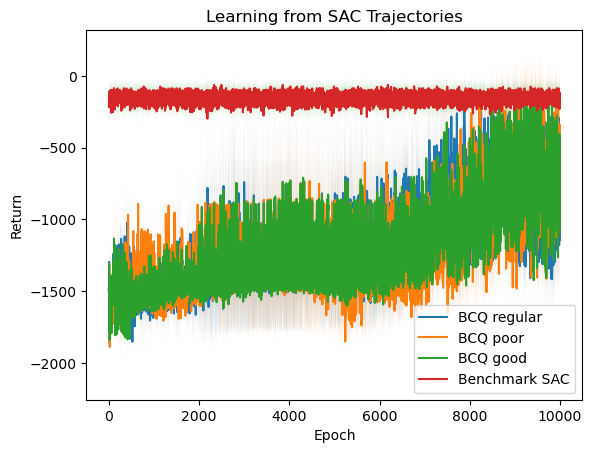

In [15]:
'''
SAC
'''
sac_means = np.mean(sac_rewards,axis=-1)
sac_stds = np.std(sac_rewards,axis=-1)
sac_means_poor = np.mean(sac_rewards_poor,axis=-1)
sac_stds_poor = np.std(sac_rewards_poor,axis=-1)
sac_means_good = np.mean(sac_rewards_good,axis=-1)
sac_stds_good = np.std(sac_rewards_good,axis=-1)
Benchmark_sac_means = np.mean(sac_benchmark_returns,axis=-1)
Benchmark_sac_stds = np.std(sac_benchmark_returns,axis=-1)

plt.plot(sac_means,label="BCQ regular")
plt.plot(sac_means_poor,label="BCQ poor")
plt.plot(sac_means_good,label="BCQ good")
plt.plot(Benchmark_sac_means,label="Benchmark SAC")
plt.fill_between(np.arange(len(sac_means)), sac_means-sac_stds, sac_means+sac_stds, alpha=0.2)
# plt.fill_between(np.arange(len(sac_means_poor)), sac_means_poor-sac_stds_poor, sac_means_poor+sac_stds_poor, alpha=0.2)
plt.fill_between(np.arange(len(sac_means_good)), sac_means_good-sac_stds_good, sac_means_good+sac_stds_good, alpha=0.2)
plt.fill_between(np.arange(len(Benchmark_sac_means)), Benchmark_sac_means-Benchmark_sac_stds, Benchmark_sac_means+Benchmark_sac_stds, alpha=0.2)
plt.xlabel("Epoch")
plt.ylabel("Return")
plt.title('Learning from SAC Trajectories')
plt.legend()
plt.show()   

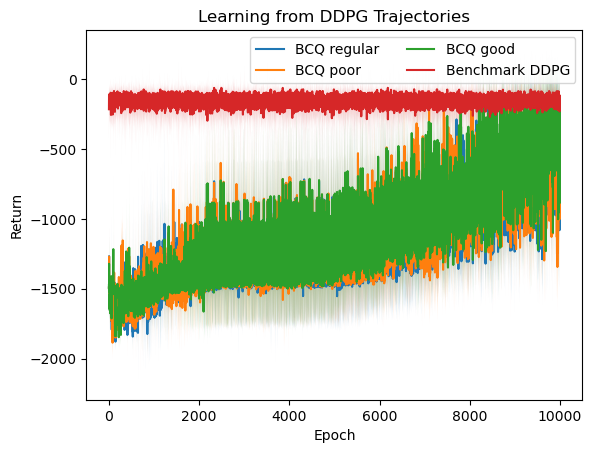

In [16]:
'''
DDPG
'''
ddpg_means = np.mean(ddpg_rewards,axis=-1)
ddpg_stds = np.std(ddpg_rewards,axis=-1)
ddpg_means_poor = np.mean(ddpg_rewards_poor,axis=-1)
ddpg_stds_poor = np.std(ddpg_rewards_poor,axis=-1)
ddpg_means_good = np.mean(ddpg_rewards_good,axis=-1)
ddpg_stds_good = np.std(ddpg_rewards_good,axis=-1)
Benchmark_means_DDPG = np.mean(ddpg_benchmark_returns,axis=-1)
Benchmark_stds_DDPG = np.std(ddpg_benchmark_returns,axis=-1)

plt.plot(ddpg_means,label="BCQ regular")
plt.plot(ddpg_means_poor,label="BCQ poor")
plt.plot(ddpg_means_good,label="BCQ good")
plt.plot(Benchmark_sac_means,label="Benchmark DDPG")
plt.fill_between(np.arange(len(ddpg_means)), ddpg_means-ddpg_stds, ddpg_means+ddpg_stds, alpha=0.2)
plt.fill_between(np.arange(len(ddpg_means_poor)), ddpg_means_poor-ddpg_stds_poor, ddpg_means_poor+ddpg_stds_poor, alpha=0.2)
plt.fill_between(np.arange(len(ddpg_means_good)), ddpg_means_good-ddpg_stds_good, ddpg_means_good+ddpg_stds_good, alpha=0.2)
plt.fill_between(np.arange(len(Benchmark_means_DDPG)), Benchmark_means_DDPG-Benchmark_stds_DDPG, Benchmark_means_DDPG+Benchmark_stds_DDPG, alpha=0.2)
plt.xlabel("Epoch")
plt.ylabel("Return")
plt.title('Learning from DDPG Trajectories')
plt.legend(ncol=2)
plt.show()   